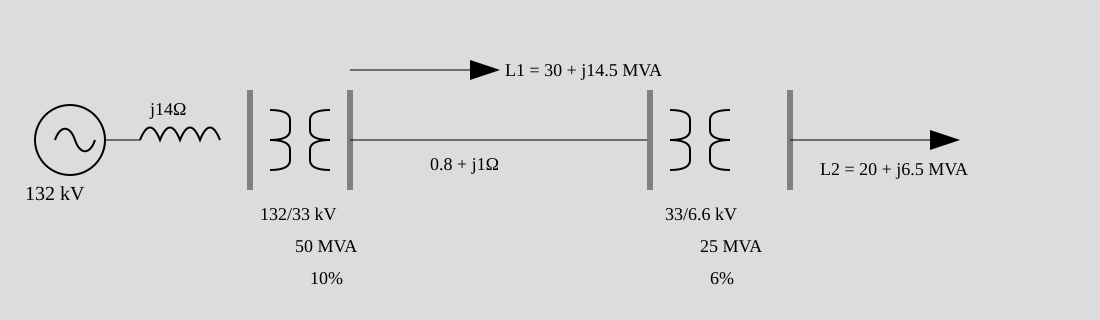

In [1]:
# TEST CELL
from myst_nb import glue
from IPython.display import SVG

svg = """
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 1100 320">
  <rect width="100%" height="100%" fill="#dcdcdc"/>

  <!-- Generator -->
  <circle cx="70" cy="140" r="35" fill="none" stroke="black" stroke-width="2"/>
  <path d="M55 140 c5 -15 15 -15 20 0 s15 15 20 0" fill="none" stroke="black" stroke-width="2"/>
  <text x="25" y="200" font-size="20">132 kV</text>

  <!-- Reactance -->
  <line x1="105" y1="140" x2="140" y2="140" stroke="black"/>
  <path d="M140 140 q10 -25 20 0 q10 -25 20 0 q10 -25 20 0 q10 -25 20 0"
        fill="none" stroke="black" stroke-width="2"/>
  <text x="150" y="115" font-size="18">j14Ω</text>

  <!-- Transformer 1 -->
  <line x1="250" y1="90" x2="250" y2="190" stroke="gray" stroke-width="6"/>
  <path d="M270 110 q20 0 20 10 v10 q0 10 -20 10 q20 0 20 10 v10 q0 10 -20 10"
        fill="none" stroke="black" stroke-width="2"/>
  <path d="M330 110 q-20 0 -20 10 v10 q0 10 20 10 q-20 0 -20 10 v10 q0 10 20 10"
        fill="none" stroke="black" stroke-width="2"/>
  <line x1="350" y1="90" x2="350" y2="190" stroke="gray" stroke-width="6"/>

  <text x="260" y="220" font-size="18">132/33 kV</text>
  <text x="295" y="252" font-size="18">50 MVA</text>
  <text x="310" y="284" font-size="18">10%</text>

  <!-- Bus -->
  <line x1="350" y1="140" x2="650" y2="140" stroke="black"/>

  <!-- Load L1 -->
  <line x1="350" y1="70" x2="470" y2="70" stroke="black"/>
  <polygon points="470,60 500,70 470,80" fill="black"/>
  <text x="505" y="76" font-size="18">L1 = 30 + j14.5 MVA</text>

  <!-- Line impedance -->
  <text x="430" y="170" font-size="18">0.8 + j1Ω</text>

  <!-- Transformer 2 -->
  <line x1="650" y1="90" x2="650" y2="190" stroke="gray" stroke-width="6"/>
  <path d="M670 110 q20 0 20 10 v10 q0 10 -20 10 q20 0 20 10 v10 q0 10 -20 10"
        fill="none" stroke="black" stroke-width="2"/>
  <path d="M730 110 q-20 0 -20 10 v10 q0 10 20 10 q-20 0 -20 10 v10 q0 10 20 10"
        fill="none" stroke="black" stroke-width="2"/>
  <line x1="790" y1="90" x2="790" y2="190" stroke="gray" stroke-width="6"/>

  <text x="665" y="220" font-size="18">33/6.6 kV</text>
  <text x="700" y="252" font-size="18">25 MVA</text>
  <text x="710" y="284" font-size="18">6%</text>

  <!-- Load L2 -->
  <line x1="790" y1="140" x2="930" y2="140" stroke="black"/>
  <polygon points="930,130 960,140 930,150" fill="black"/>
  <text x="820" y="175" font-size="18">L2 = 20 + j6.5 MVA</text>
</svg>
"""

glue("last_flyt", SVG(svg), display=True)

Først må vi se hvilke verdier vi har her:
- Et ekstern nett på 132 kV
- tilhørende $X_s$ = j14
- 50 Mva trafo på 0.1
- 25 MVA trafo på 0.06
- P,Q, bus på 20 + j6.5 MVA


In [2]:
import pandapower as pp

In [4]:
#create empty net
net = create_empty_network()

In [ ]:


#create buses
bus1 = create_bus(net, vn_kv=132., name="Bus 1")
bus2 = create_bus(net, vn_kv=0.4, name="Bus 2")
bus3 = create_bus(net, vn_kv=0.4, name="Bus 3")

#create bus elements
create_ext_grid(net, bus=bus1, vm_pu=1.0, name="Grid Connection")
create_load(net, bus=bus3, p_mw=0.100, q_mvar=0.05, name="Load")

#create branch elements
trafo = create_transformer(net, hv_bus=bus1, lv_bus=bus2, std_type="0.5 MVA 132/33 kV", name="Trafo")
line = create_line(net, from_bus=bus2, to_bus=bus3, length_km=0.1, std_type="NAYY 4x50 SE", name="Line")